In [381]:
import glob
import os
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
from IPython.display import display

import ldparser
from ldparser import ldData

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import silhouette_score

In [382]:
import glob
import ldparser
from ldparser import ldData

# 1. Eine der .ld-Dateien heraussuchen
ld_files = glob.glob("raw_data/*.ld")
if ld_files:
    test_file = ld_files[0]
    print(f"[Spion] Lese Testdatei aus: {test_file}\n")
    
    # 2. Die Datei roh einlesen (bevor irgendein Mapping passiert)
    telemetry_tuple = ldData.fromfile(test_file)
    
    # 3. Alle echten Kanalnamen alphabetisch ausgeben
    print("--- ALLE VERFÜGBAREN ORIGINAL-KANÄLE IN DEINER DATEI ---")
    
    # KORREKTUR: Wir holen uns die Namen aus der internen .channs-Liste der Bibliothek
    kanal_namen = [kanal_objekt.name for kanal_objekt in telemetry_tuple.channs]
    
    for kanal in sorted(kanal_namen):
        print(f" -> '{kanal}'")
else:
    print("[FEHLER] Keine .ld-Dateien im Ordner 'raw_data/' gefunden!")

[Spion] Lese Testdatei aus: raw_data/ks_nurburgring_&_ks_porsche_911_gt3_rs_&_THTH312_&_stint_1.ld

--- ALLE VERFÜGBAREN ORIGINAL-KANÄLE IN DEINER DATEI ---
 -> 'ABS Active'
 -> 'ABS Enabled'
 -> 'AID Allow Tire Blankets'
 -> 'AID Auto Blip'
 -> 'AID Auto Clutch'
 -> 'AID Auto Shift'
 -> 'AID Fuel Rate'
 -> 'AID Ideal Line'
 -> 'AID Mech Damage'
 -> 'AID Stability'
 -> 'AID Tire Wear Rate'
 -> 'Air Density'
 -> 'Air Temp'
 -> 'Ballast'
 -> 'Best Lap Delta'
 -> 'Best Lap Time'
 -> 'Brake Bias'
 -> 'Brake Pos'
 -> 'Brake Temp FL'
 -> 'Brake Temp FR'
 -> 'Brake Temp RL'
 -> 'Brake Temp RR'
 -> 'CG Accel Lateral'
 -> 'CG Accel Longitudinal'
 -> 'CG Accel Vertical'
 -> 'CG Height'
 -> 'Camber FL'
 -> 'Camber FR'
 -> 'Camber RL'
 -> 'Camber RR'
 -> 'Car Coord X'
 -> 'Car Coord Y'
 -> 'Car Coord Z'
 -> 'Car Damage Front'
 -> 'Car Damage Left'
 -> 'Car Damage Rear'
 -> 'Car Damage Right'
 -> 'Car Pos Norm'
 -> 'Caster FL'
 -> 'Caster FR'
 -> 'Chassis Pitch Angle'
 -> 'Chassis Pitch Rate'
 -> '

In [383]:
ld_data = glob.glob("raw_data/*.ld")
print(f"[Info] {len(ld_data)} Telemetriedateien im Ordner gefunden.")

channel_tuple_mapping = {
    'Steering Angle': 'steering_angle',
    'Throttle Pos': 'throttle_pos',
    'Brake Pos': 'brake_pos',
    'Engine RPM': 'engine_rpm',
    'Wheel Angular Speed FL': 'speed_fl',
}

[Info] 5 Telemetriedateien im Ordner gefunden.


In [384]:
master_feature_liste = []

for ld_file in ld_data:
    timestamp_in_seconds = []
    ldx_file = ld_file.replace('.ld', '.ldx')

    # LDX-Datei einlesen und Zeitstempel der Beacons extrahieren
    try: 
        ldx_file_tree = ET.parse(ldx_file)
        ldx_file_root = ldx_file_tree.getroot()

        for beacon in ldx_file_root.findall('.//MarkerGroup[@Name="Beacons"]/Marker'):
            time_node = beacon.get('Time')

            if time_node is not None:
                time_node_in_seconds = float(time_node) / 1000000.0
                timestamp_in_seconds.append(time_node_in_seconds)
    except Exception as e:
        print(f"\n{e}")

    # LD-Datei einlesen und relevante Kanäle extrahieren
    telemetry_tuple = ldData.fromfile(ld_file)
    channel_data = {}
    for ld_name, htf_name in channel_tuple_mapping.items():
        
        if ld_name in telemetry_tuple:
            channel_object = telemetry_tuple[ld_name]
            channel_data[htf_name] = pd.Series(data=channel_object.data, index=np.arange(len(channel_object.data)) / getattr(channel_object, 'freq'))

            df_telemetry = pd.DataFrame(channel_data)

        else:
            print(f"\n{e}")
    

    for i in range(len(timestamp_in_seconds) - 1):
        # Zeit der Fahrer pro Rundenabschnitt extrahieren
        start_time = timestamp_in_seconds[i]
        end_time = timestamp_in_seconds[i + 1]
        
        curve_data = df_telemetry[(df_telemetry.index >= start_time) & (df_telemetry.index < end_time)]
        if curve_data.empty:
            continue

        # Fahrer-ID aus dem Dateinamen extrahieren
        file_name = os.path.basename(ld_file)
        data_name_parted = file_name.split('_&_')
        
        if len(data_name_parted) >= 3:
            driver_id = data_name_parted[2]
        else:
            driver_id = file_name
            
        feature = {
            'Fahrer_ID': driver_id,
            'Segment_Nummer': i + 1,

            # Die biometrischen Features (Mensch)
            'lenkung_unruhe': curve_data['steering_angle'].var() if 'steering_angle' in curve_data else 0,
            'gas_schnitt': curve_data['throttle_pos'].mean() if 'throttle_pos' in curve_data else 0,
            'gas_streuung': curve_data['throttle_pos'].var() if 'throttle_pos' in curve_data else 0,
            'brems_haerte': curve_data['brake_pos'].max() if 'brake_pos' in curve_data else 0,
            'brems_streuung': curve_data['brake_pos'].var() if 'brake_pos' in curve_data else 0,
            'drehzahl_schnitt': curve_data['engine_rpm'].mean() if 'engine_rpm' in curve_data else 0,

            # Die Physik-Kontext
            'geschw_schnitt': curve_data['speed_fl'].mean() if 'speed_fl' in curve_data else 0,
            'geschw_streuung': curve_data['speed_fl'].var() if 'speed_fl' in curve_data else 0,
        }
        master_feature_liste.append(feature)

df_master_ml = pd.DataFrame(master_feature_liste)
display(df_master_ml)

,Fahrer_ID,Segment_Nummer,lenkung_unruhe,gas_schnitt,gas_streuung,brems_haerte,brems_streuung,drehzahl_schnitt,geschw_schnitt,geschw_streuung
0,THTH312,1,998.256777,57.189121,2108.418377,82.555,212.501812,5166.962964,78.728081,1468.771578
1,THTH312,2,954.323476,55.857064,2026.340740,83.725,164.500406,4432.270926,65.150724,1647.117390
2,THTH312,3,676.892522,44.164949,1941.228849,85.825,138.703913,5487.661716,74.061532,1258.974197
3,THTH312,4,1227.790588,63.927879,2040.631864,100.000,693.759834,5322.258459,78.693141,1024.882434
4,THTH312,5,1494.198904,59.265656,2065.338039,100.000,427.466940,4714.533022,73.625121,1614.937987
5,THTH312,6,852.081316,76.774462,1669.076148,100.000,940.644809,4402.911092,80.377248,1059.803257
6,ALAD201,1,1023.994989,39.605137,656.352318,49.975,66.435280,3740.819135,65.151012,1480.804867
7,ALAD201,2,1132.537668,47.429426,831.817614,100.000,329.511068,4278.762948,68.343661,1242.462435
8,ALAD201,3,2214.514927,43.982702,870.623628,100.000,477.875373,4344.595531,66.787381,1531.662643
9,ALAD201,4,989.528849,56.695627,890.717794,100.000,695.665083,4482.980502,79.824516,1016.313123



--- STATISTISCHER REPORT FÜR DEINE THESIS ---
Hauptkomponente 1 (PC1): Erklärt 40.4% der gesamten Fahrer-Unterschiede.
Hauptkomponente 2 (PC2): Erklärt 23.9% der gesamten Fahrer-Unterschiede.
Hauptkomponente 3 (PC3): Erklärt 12.0% der gesamten Fahrer-Unterschiede.
-> Gesamte erklärte Wahrheit im 3D-Raum: 76.3%
-------------------------------------------------



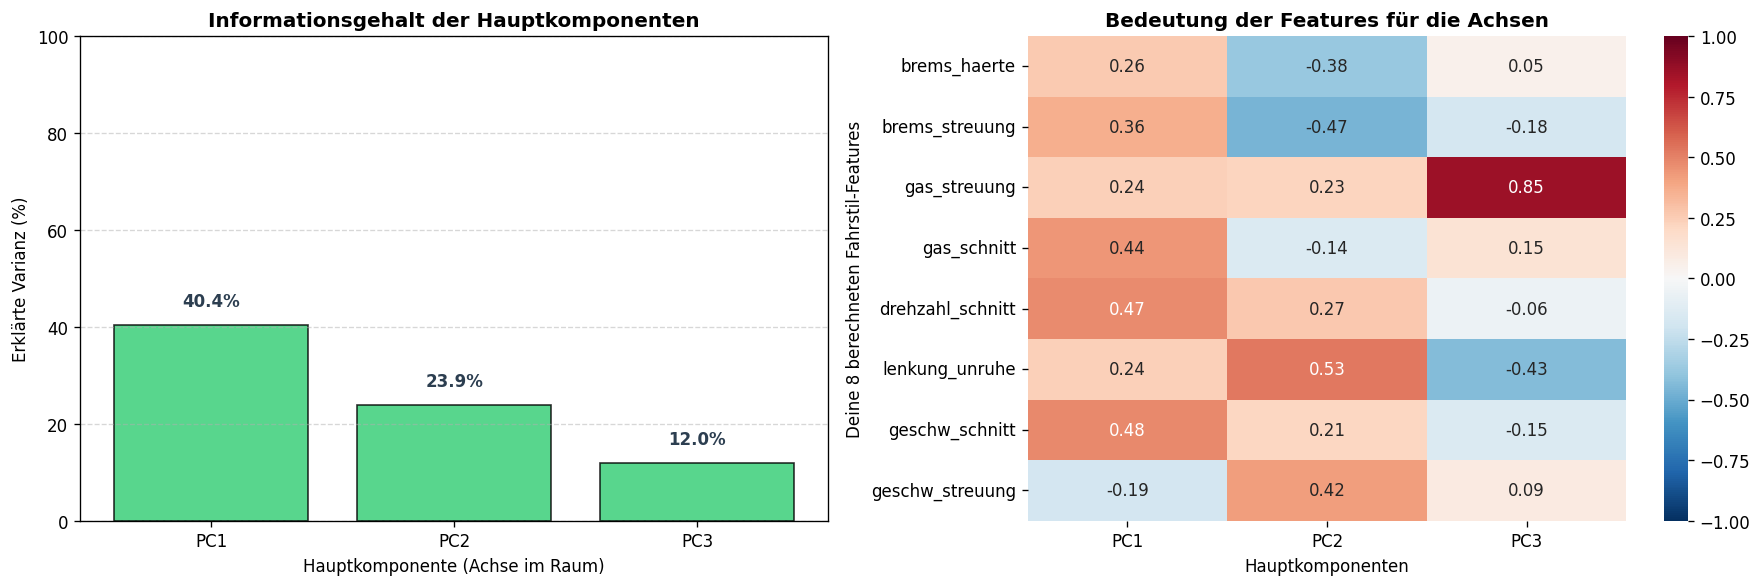

In [385]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    # 1. Reine Feature-Matrix isolieren (Metadaten weglassen)
    spalten_fuer_pca = [ 
        'brems_haerte', 'brems_streuung', 
        'gas_streuung', 'gas_schnitt', 
        'drehzahl_schnitt', 'lenkung_unruhe', 
        'geschw_schnitt', 'geschw_streuung',
    ]
    
    # Prüfen, ob alle Spalten da sind
    vorhandene_features = [f for f in spalten_fuer_pca if f in df_master_ml.columns]
    X_pca_input = df_master_ml[vorhandene_features]

    # 2. Skalierung (Absolut Pflicht vor einer PCA!)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_pca_input)

    # 3. PCA berechnen (Wir schauen uns die ersten 3 Hauptkomponenten an)
    pca = PCA(n_components=3)
    X_projected = pca.fit_transform(X_scaled)
    var_exp = pca.explained_variance_ratio_

    # --- TEXT-REPORT FÜR DEINE UNTERLAGEN ---
    print("\n--- STATISTISCHER REPORT FÜR DEINE THESIS ---")
    for idx, anteil in enumerate(var_exp):
        print(f"Hauptkomponente {idx+1} (PC{idx+1}): Erklärt {anteil*100:.1f}% der gesamten Fahrer-Unterschiede.")
    print(f"-> Gesamte erklärte Wahrheit im 3D-Raum: {sum(var_exp)*100:.1f}%")
    print("-------------------------------------------------\n")

    # --- GRAFIK 1: DER SCREE-PLOT (Erklärte Varianz) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=120)
    
    komponenten_labels = [f"PC{i+1}" for i in range(len(var_exp))]
    bars = ax1.bar(komponenten_labels, var_exp * 100, color='#2ecc71', edgecolor='k', alpha=0.8)
    ax1.set_title("Informationsgehalt der Hauptkomponenten", fontweight='bold', fontsize=12)
    ax1.set_xlabel("Hauptkomponente (Achse im Raum)")
    ax1.set_ylabel("Erklärte Varianz (%)")
    ax1.set_ylim(0, 100)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Prozentzahlen auf die Säulen schreiben
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 3, f"{height:.1f}%", 
                 ha='center', va='bottom', fontweight='bold', color='#2c3e50')

    # --- GRAFIK 2: FEATURE LOADINGS HEATMAP (Deine Feature-Vorstellung!) ---
    # Hier wird berechnet, wie stark jedes deiner 8 Features auf die Achsen abfärbt
    loadings = pd.DataFrame(
        pca.components_.T, 
        columns=[f'PC1', f'PC2', f'PC3'], 
        index=vorhandene_features
    )
    
    sns.heatmap(loadings, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", ax=ax2, cbar=True)
    ax2.set_title("Bedeutung der Features für die Achsen", fontweight='bold', fontsize=12)
    ax2.set_ylabel("Deine 8 berechneten Fahrstil-Features")
    ax2.set_xlabel("Hauptkomponenten")
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Fehler bei der Varianz-Analyse: {e}")

In [386]:
import pandas as pd
import glob
import os

csv_data = glob.glob('processed_data/*.csv')
all_driver_data = []

for data_file in csv_data:
    dateiname = os.path.basename(data_file)
    probanden_id = dateiname.split('_')[0] 
    
    df_temp = pd.read_csv(data_file, skiprows=7)
    
    df_temp['Fahrer_ID'] = probanden_id
    
    all_driver_data.append(df_temp)

# Alle Tabellen zu einem riesigen Master-DataFrame zusammenkleben
df_master_ml_real = pd.concat(all_driver_data, ignore_index=True)

print(f"[OK] {len(csv_data)} Probanden-Dateien erfolgreich geladen!")
print(f"-> Gefundene IDs: {df_master_ml_real['Fahrer_ID'].unique()}")

[OK] 10 Probanden-Dateien erfolgreich geladen!
-> Gefundene IDs: <StringArray>
['TOINZ27000', 'INBWZ11002', 'MAAKZ19001', 'CHIPZ26000', 'PASZZ20000',
 'MAMCZ06001']
Length: 6, dtype: str


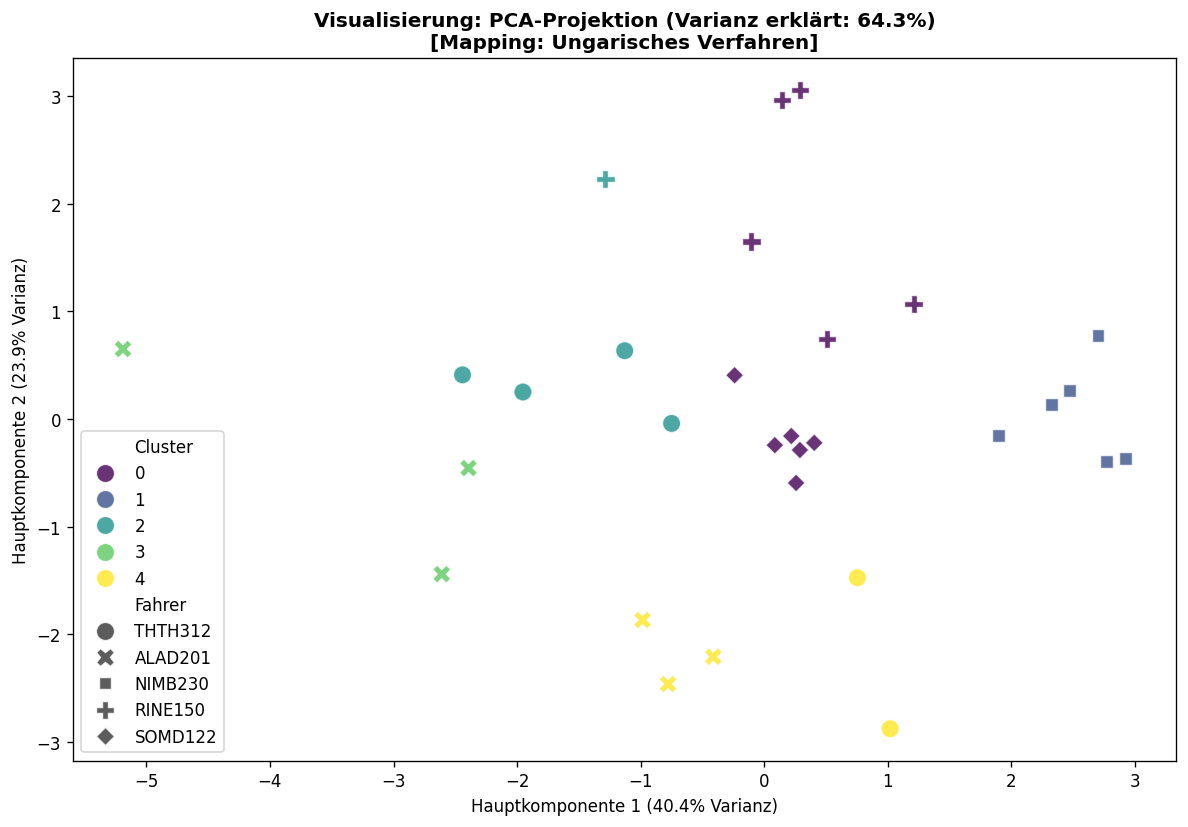

Silhouette Score (Qualität der Trennung): 0.305


In [387]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

try: 
    # 1. Daten vorbereiten (Zusätzliche Sicherheits-Drops, falls die Zelle mehrfach läuft)
    spalten_zum_loeschen = [
        'Fahrer_ID', 'Segment_Nummer', 'Fahrstil_Cluster_ID', 
        'Vorhergesagter_Fahrer', 'Vorhergesagter_Cluster', 'Erkannter_Fahrer'
    ]
    x_clustering = df_master_ml.drop(columns=spalten_zum_loeschen, errors='ignore')

    # 2. Skalieren (WICHTIG für K-Means und PCA!)
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_clustering)

    # 3. K-Means Training (Wir nehmen die Anzahl der Fahrer als Cluster-Anzahl)
    num_drivers = df_master_ml['Fahrer_ID'].nunique()
    kmeans_final = KMeans(n_clusters=num_drivers, random_state=42, n_init=100)
    df_master_ml['Fahrstil_Cluster_ID'] = kmeans_final.fit_predict(x_scaled)

    # ungarische Methode
    contingency_matrix = pd.crosstab(df_master_ml['Fahrer_ID'], df_master_ml['Fahrstil_Cluster_ID'])
    cost_matrix = -contingency_matrix.values
    fahrer_indizes, cluster_indizes = linear_sum_assignment(cost_matrix)

    # konfliktfreie 1-zu-1 Mapping-Wörterbuch befüllen
    cluster_to_driver = {}
    for f_idx, c_idx in zip(fahrer_indizes, cluster_indizes):
        echter_fahrer_name = contingency_matrix.index[f_idx]
        cluster_id = contingency_matrix.columns[c_idx]
        cluster_to_driver[cluster_id] = echter_fahrer_name
        
    # Zuweisung auf das Master-DataFrame anwenden
    df_master_ml['Vorhergesagter_Fahrer'] = df_master_ml['Fahrstil_Cluster_ID'].map(cluster_to_driver)
    
    # PCA zur Visualisierung (Dimensionalitätsreduktion)
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(x_scaled)
    df_pca = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])
    df_pca['Fahrer'] = df_master_ml['Fahrer_ID'].values
    df_pca['Cluster'] = df_master_ml['Fahrstil_Cluster_ID'].values

    # Plotten
    plt.figure(figsize=(10, 7), dpi=120)
    sns.scatterplot(
        data=df_pca,
        x='PC1',
        y='PC2',
        hue='Cluster',
        style='Fahrer',
        palette='viridis',
        s=120,
        alpha=0.8
    )
    
    # Erklärte Varianz anzeigen (sehr wichtig für die Thesis!)
    var_exp = pca.explained_variance_ratio_
    plt.title(f"Visualisierung: PCA-Projektion (Varianz erklärt: {sum(var_exp):.1%})\n[Mapping: Ungarisches Verfahren]", fontweight='bold')
    plt.xlabel(f"Hauptkomponente 1 ({var_exp[0]:.1%} Varianz)")
    plt.ylabel(f"Hauptkomponente 2 ({var_exp[1]:.1%} Varianz)")
    plt.tight_layout()
    plt.show()

    # Score ausgeben
    score = silhouette_score(x_scaled, df_master_ml['Fahrstil_Cluster_ID'])
    print(f"Silhouette Score (Qualität der Trennung): {score:.3f}")

except Exception as e:
    print(f"\n[FAIL] Kritischer Fehler in der AI-Sektion: {e}")

[Daten] Unterricht (Training): 25 Runden
[Daten] Echte Klausur (Test): 5 Runden

--- Ergebnis der Klausur (Ungarisches Verfahren) ---
              precision    recall  f1-score   support

     ALAD201       1.00      1.00      1.00         1
     NIMB230       1.00      1.00      1.00         1
     RINE150       0.00      0.00      0.00         1
     SOMD122       1.00      1.00      1.00         1
     THTH312       0.50      1.00      0.67         1

    accuracy                           0.80         5
   macro avg       0.70      0.80      0.73         5
weighted avg       0.70      0.80      0.73         5



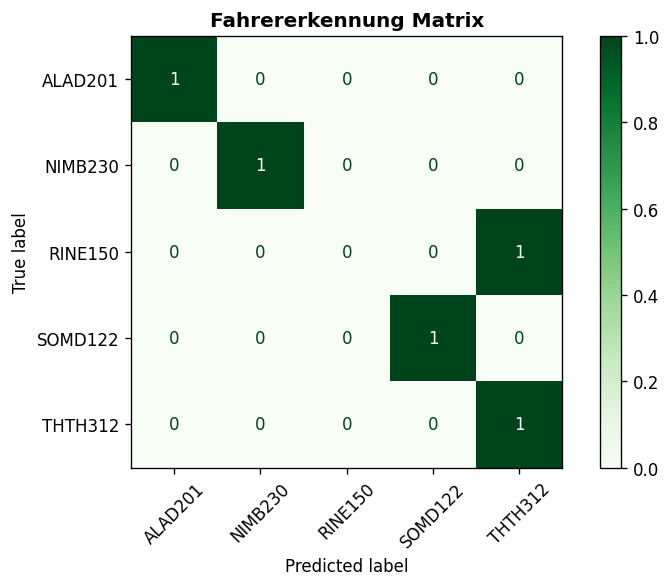

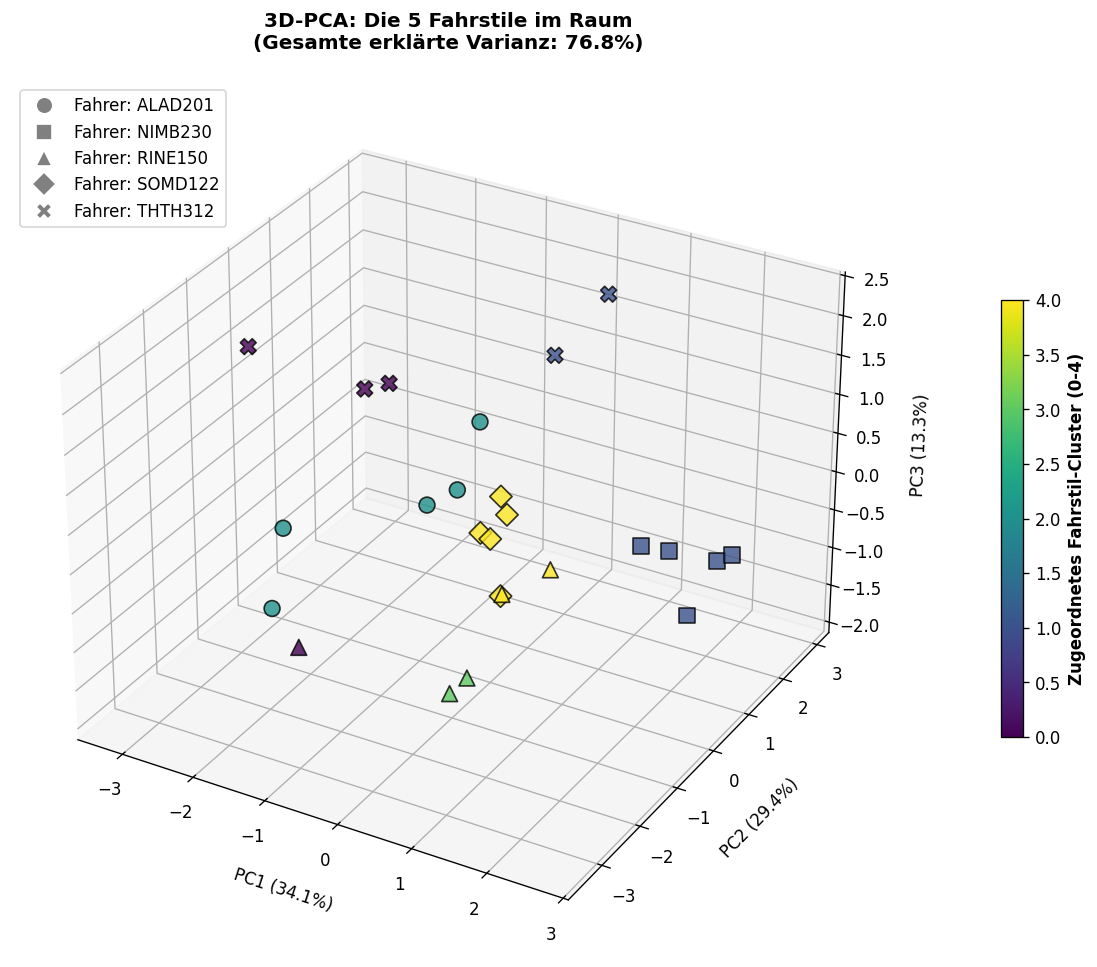

In [388]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

try:
    # --- JEDER Fahrer hat exakt 6 Runden insgesamt ---
    # Wir ziehen von jedem Fahrer genau 1 ungesehene Runden für die Klausur
    test_df = df_master_ml.groupby('Fahrer_ID').sample(n=1, random_state=42).copy()
    
    # Die restlichen 4 Runden pro Fahrer wandern ins Training
    train_df = df_master_ml.drop(test_df.index).copy()
    
    print(f"[Daten] Unterricht (Training): {len(train_df)} Runden")
    print(f"[Daten] Echte Klausur (Test): {len(test_df)} Runden")

    # Datenentfernung für die reine Feature-Matrix
    spalten_zum_loeschen = [
        'Fahrer_ID', 
        'Segment_Nummer', 
        'Fahrstil_Cluster_ID', 
        'Vorhergesagter_Fahrer',
        'Vorhergesagter_Cluster',
        'Erkannter_Fahrer',
        'Cluster_ID'
    ]
    
    X_train = train_df.drop(columns=spalten_zum_loeschen, errors='ignore')
    X_test = test_df.drop(columns=spalten_zum_loeschen, errors='ignore')

    # Skalieren
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) 

    # Training (K-Means sucht nach den 5 Fahrstilen im 8D-Raum)
    num_drivers = train_df['Fahrer_ID'].nunique()  
    kmeans = KMeans(n_clusters=num_drivers, random_state=42, n_init=100)
    train_df['Cluster_ID'] = kmeans.fit_predict(X_train_scaled)

    # ungarische Methode
    contingency_matrix = pd.crosstab(train_df['Fahrer_ID'], train_df['Cluster_ID'])
    cost_matrix = -contingency_matrix.values
    fahrer_indizes, cluster_indizes = linear_sum_assignment(cost_matrix)

    cluster_zu_fahrer = {}
    for f_idx, c_idx in zip(fahrer_indizes, cluster_indizes):
        echter_fahrer_name = contingency_matrix.index[f_idx]
        cluster_id = contingency_matrix.columns[c_idx]
        cluster_zu_fahrer[cluster_id] = echter_fahrer_name

    # Vorhersage auf den ungesehenen Runden pro Fahrer
    test_df['Vorhergesagter_Cluster'] = kmeans.predict(X_test_scaled)
    test_df['Erkannter_Fahrer'] = test_df['Vorhergesagter_Cluster'].map(cluster_zu_fahrer)

    y_true_test = test_df['Fahrer_ID']
    y_pred_test = test_df['Erkannter_Fahrer']
    
    print("\n--- Ergebnis der Klausur (Ungarisches Verfahren) ---")
    print(classification_report(y_true_test, y_pred_test, zero_division=0))

    # --- GRAFIK 1: Confusion Matrix ---
    cm = confusion_matrix(y_true_test, y_pred_test)
    labels = sorted(y_true_test.unique())
    
    fig1, ax1 = plt.subplots(figsize=(7, 5), dpi=120)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax1, cmap=plt.cm.Greens, xticks_rotation=45)
    plt.title("Fahrererkennung Matrix", fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- GRAFIK 2: Der 3-Dimensionale Fahrstil-Raum (3D-PCA) ---
    pca_3d = PCA(n_components=3)
    X_train_pca = pca_3d.fit_transform(X_train_scaled)
    
    fig2 = plt.figure(figsize=(10, 8), dpi=120)
    ax2 = fig2.add_subplot(111, projection='3d')
    
    markers = ['o', 's', '^', 'D', 'X']
    vmin = train_df['Cluster_ID'].min()
    vmax = train_df['Cluster_ID'].max()
    
    # Plotten der Punkte im Raum (Farbe = Cluster, Form = Echter Fahrer)
    for i, fahrer in enumerate(sorted(train_df['Fahrer_ID'].unique())):
        mask = train_df['Fahrer_ID'] == fahrer
        ax2.scatter(
            X_train_pca[mask, 0], 
            X_train_pca[mask, 1], 
            X_train_pca[mask, 2],
            c=train_df.loc[mask, 'Cluster_ID'], 
            cmap='viridis', 
            marker=markers[i % len(markers)],
            s=90, 
            vmin=vmin, 
            vmax=vmax,
            edgecolor='k',
            alpha=0.8
        )
    
    # Farbskala für die Cluster hinzufügen
    mappable = plt.cm.ScalarMappable(cmap='viridis')
    mappable.set_array(train_df['Cluster_ID'])
    cbar = fig2.colorbar(mappable, ax=ax2, pad=0.1, shrink=0.5)
    cbar.set_label('Zugeordnetes Fahrstil-Cluster (0-4)', fontweight='bold')
    
    # Achsenbeschriftung mit der exakt erklärten Varianz der Hauptkomponenten
    var_exp = pca_3d.explained_variance_ratio_
    ax2.set_title(f"3D-PCA: Die 5 Fahrstile im Raum\n(Gesamte erklärte Varianz: {sum(var_exp):.1%})", fontweight='bold', pad=20)
    ax2.set_xlabel(f"PC1 ({var_exp[0]:.1%})", labelpad=10)
    ax2.set_ylabel(f"PC2 ({var_exp[1]:.1%})", labelpad=10)
    ax2.set_zlabel(f"PC3 ({var_exp[2]:.1%})", labelpad=10)
    
    # Saubere Legende für die echten Fahrer-IDs bauen
    legend_elements = [
        Line2D([0], [0], marker=markers[i % len(markers)], color='w', 
               markerfacecolor='gray', markersize=10, label=f"Fahrer: {fahrer}")
        for i, fahrer in enumerate(sorted(train_df['Fahrer_ID'].unique()))
    ]
    ax2.legend(handles=legend_elements, loc='upper left')
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Kritischer Fehler im Test-Modul: {e}")